**NOTE:** Some variable names differ from those used in the main text, 
reflecting terminology changes made during the course of the study:
- 'fold' -> 'fold lineage', 'lineage'
- 'NONE' -> 'base seed'
- 'ALL' -> 'full network'

Each enzyme-gated network expansion run records iterations of network expansion as follows:
- cumiter: Tracks all individual expansion steps, including both lineage addition steps and the resulting standard network expansion steps
- folditer: Groups each lineage addition and the subsequent network expansion into a single unit; corresponds to a metabolic stage

In [1]:
from utils import*

In [2]:
# DS average
a_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv'
b_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv'
e_path = '../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv'
ab_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv'
abe_path = '../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBacEuk_recovered.csv'

xgroup2ds_a = csv2dict(a_path)
print(len(xgroup2ds_a))
xgroup2ds_b = csv2dict(b_path)
print(len(xgroup2ds_b))
xgroup2ds_e = csv2dict(e_path)
print(len(xgroup2ds_e))
xgroup2ds_ab = csv2dict(ab_path)
print(len(xgroup2ds_ab))
xgroup2ds_abe = csv2dict(abe_path)
print(len(xgroup2ds_abe))

2230
2230
2230
2230
2230


In [3]:
# new results

# NONE (base seed) 1000 runs
df_folds_folditer = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_NONE.csv', index_col=0)

# Draw iterVSds

In [4]:
run2iter2ds = {}
for run in df_folds_folditer.columns:
    iter2ds = {}
    for x, i in df_folds_folditer[run].items():
        if x not in ['fold_independent', 'spontaneous']:
            if i not in iter2ds:
                iter2ds[i] = [x2ds[x]]
            else:
                iter2ds[i].append(x2ds[x])
    iter2ds_mean = {k:np.mean(v) for k,v in iter2ds.items()}
    run2iter2ds[run] = iter2ds_mean

iter2ds_mean_all = {}
for run, iter2ds in run2iter2ds.items():
    for i, ds in iter2ds.items():
        if i not in iter2ds_mean_all:
            iter2ds_mean_all[i] = [ds]
        else:
            iter2ds_mean_all[i].append(ds)
# take average over 1000 runs
iter2ds_mean_all_mean = {k:np.mean(v) for k,v in iter2ds_mean_all.items()}
iter2ds_mean_all_std = {k:np.std(v) for k,v in iter2ds_mean_all.items()}

folditer vs. average ds at folditer:
p_value = 1.027202768310673e-108, corr = -0.8589382445173462


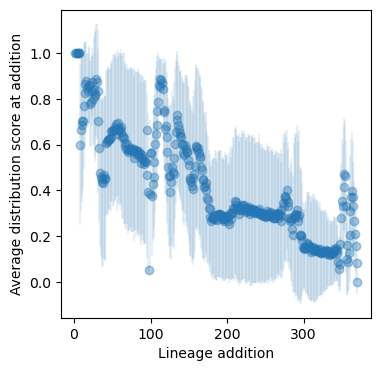

In [5]:
# std for error bar

y = list(iter2ds_mean_all_mean.values())  # average dist score
x = list(iter2ds_mean_all_mean.keys())  # iteration number
y_err = list(iter2ds_mean_all_std.values())  # variability 

# print Spearman correlation coeff.
corr, p = spearmanr(x, y)
print(f'folditer vs. average ds at folditer:')
print(f'p_value = {p}, corr = {corr}')

# Create a scatterplot with error bars
plt.figure(figsize=(4, 4))
plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.1, color='#2576B4')  # errorbar + data points
plt.scatter(x, y, marker='o', color='#2576B4', alpha = 0.3, zorder=2)  # data points (overlay to increase alpha)
plt.ylabel('Average distribution score at addition')
plt.xlabel('Lineage addition')
# plt.savefig('iterVSds_range_std_error_2.png', dpi=300, bbox_inches = 'tight')
plt.show()

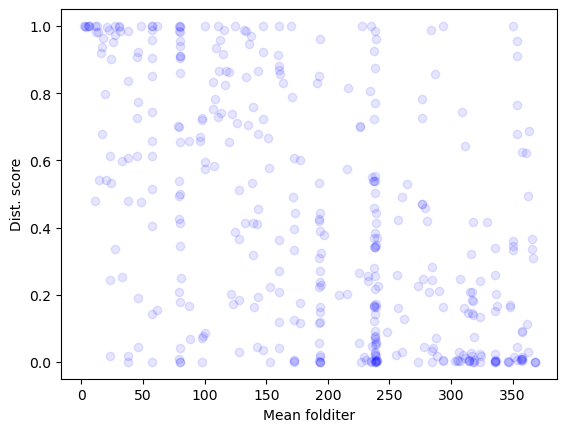

In [6]:
x2foMean = {}
x2foStd = {}
for x in df_folds_folditer.index:
    if x not in ['fold_independent', 'spontaneous']:
        x2foMean[x] = np.mean(df_folds_folditer.loc[x])
        x2foStd[x] = np.std(df_folds_folditer.loc[x])

scatter(x2foMean, x2ds, 'Mean folditer', 'Dist. score')

In [7]:
x2foStd['2010'], x2foStd['301'], x2foStd['590']

(121.79818512605213, 1.3957044816149338, 121.79818512605213)

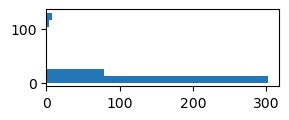

In [8]:
data1 = list(x2foStd.values())
plt.figure(figsize=(3, 1))
plt.hist(data1, bins=10, color='#2576B4', edgecolor=None, orientation='horizontal')
# plt.ylabel('Std.')
# plt.xlabel('Lineage Count')

# plt.yscale('log', nonpositive='clip')
# plt.savefig('inset.svg', dpi=300, bbox_inches = 'tight')

plt.show()

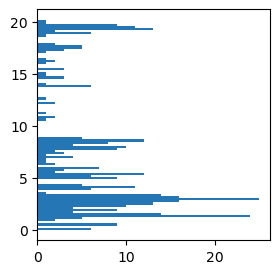

In [9]:
data1 = [x for x in list(x2foStd.values()) if x < 30]
plt.figure(figsize=(3, 3))
plt.hist(data1, bins=100, color='#2576B4', edgecolor=None, orientation='horizontal')

plt.show()

In [10]:
len([x for x in list(x2foStd.values()) if x < 20]), len([x for x in list(x2foStd.values()) if x < 10])

(380, 295)

## adjust for "oscillation"

368.02


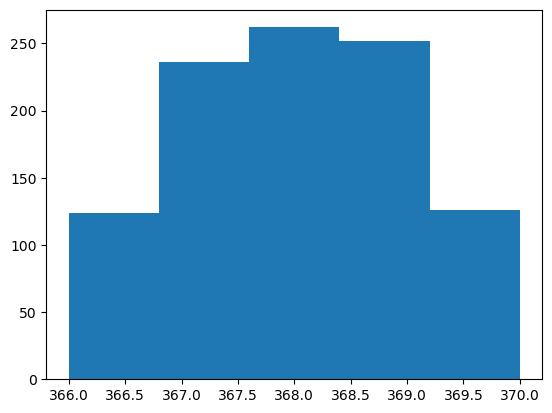

In [11]:
lengths = []
for run in df_folds_folditer.columns:
    lengths.append(max(df_folds_folditer[run]))
print(np.mean(lengths))
plt.hist(lengths, bins=5)
plt.show()
lengths = set(lengths)

folditer vs. average ds at folditer:
p_value = 1.7163196688057583e-90, corr = -0.8212795683660353


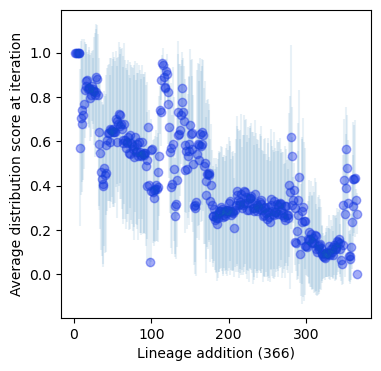

folditer vs. average ds at folditer:
p_value = 1.8915043799328555e-96, corr = -0.8349677518917094


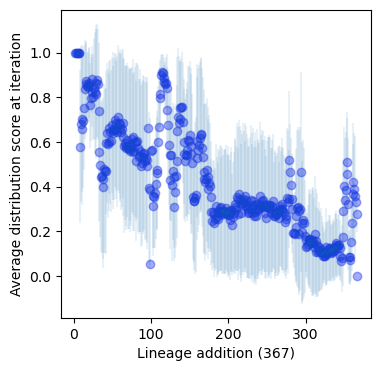

folditer vs. average ds at folditer:
p_value = 4.7638263257367586e-102, corr = -0.8466855064544889


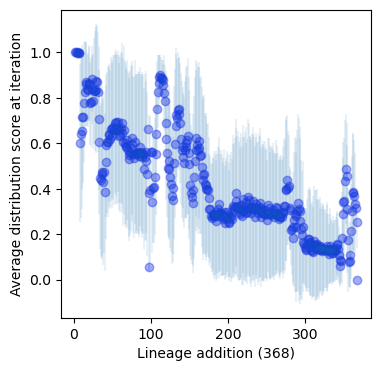

folditer vs. average ds at folditer:
p_value = 1.0084771274647088e-104, corr = -0.851638709076219


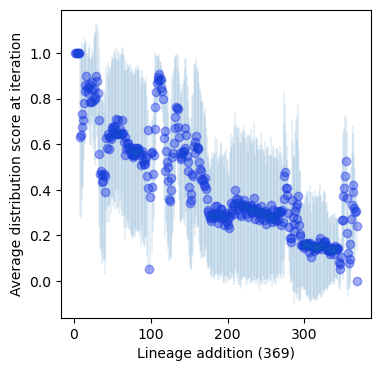

folditer vs. average ds at folditer:
p_value = 2.787116806352812e-97, corr = -0.8350851482166587


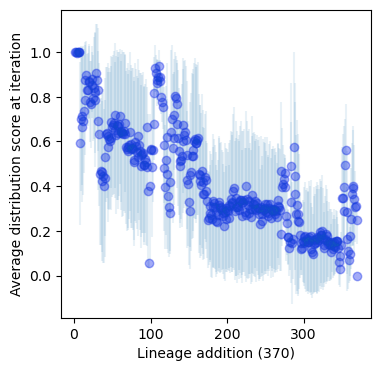

In [12]:
for length in lengths:
    run2iter2ds = {}
    
    for run in df_folds_folditer.columns:
        iter2ds = {}
        for x, i in df_folds_folditer[run].items():
            if x not in ['fold_independent', 'spontaneous']:
                if i not in iter2ds:
                    iter2ds[i] = [x2ds[x]]
                else:
                    iter2ds[i].append(x2ds[x])
        iter2ds_mean = {k:np.mean(v) for k,v in iter2ds.items()}
        
        if max(df_folds_folditer[run]) == length:  # check length
            run2iter2ds[run] = iter2ds_mean
    
    
    iter2ds_mean_all = {}
    for run, iter2ds in run2iter2ds.items():
        for i, ds in iter2ds.items():
            if i not in iter2ds_mean_all:
                iter2ds_mean_all[i] = [ds]
            else:
                iter2ds_mean_all[i].append(ds)
                
    # take average over 1000 runs
    iter2ds_mean_all_mean = {k:np.mean(v) for k,v in iter2ds_mean_all.items()}
    iter2ds_mean_all_std = {k:np.std(v) for k,v in iter2ds_mean_all.items()}
    
    
    # plot
    y = list(iter2ds_mean_all_mean.values())  # average dist score
    x = list(iter2ds_mean_all_mean.keys())  # iteration number
    y_err = list(iter2ds_mean_all_std.values())  # variability 
    
    # print Spearman's correlation coeff.
    corr, p = spearmanr(x, y)
    print(f'folditer vs. average ds at folditer:')
    print(f'p_value = {p}, corr = {corr}')
    
    # Create a scatterplot with error bars
    plt.figure(figsize=(4, 4))
    plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.1)  # errorbar + data points
    plt.scatter(x, y, marker='o', color='b', alpha = 0.3, zorder=2)  # data points (overlay to increase alpha)
    plt.ylabel('Average distribution score at iteration')
    plt.xlabel(f'Lineage addition ({length})')
    
    plt.show()

# Draw plot for all pre_expansions

In [13]:
df_NONE = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_NONE.csv', index_col=0)
df_Z00035 = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_Z00035.csv', index_col=0)
df_C00002 = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_C00002.csv', index_col=0)
df_C00004 = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_C00004.csv', index_col=0)
df_C00019 = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_C00019.csv', index_col=0)
df_C00010 = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_C00010.csv', index_col=0)
df_C00016 = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_C00016.csv', index_col=0)
df_Z00047 = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_Z00047.csv', index_col=0)
df_Z00009 = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_Z00009.csv', index_col=0)
df_ALL = pd.read_csv('../data/1000runs_csvs/folds_folditer_pre-expansion_1000runs/folds_folditer_ALL.csv', index_col=0)

pre2dfs = {'NONE':df_NONE, 'Z00035': df_Z00035, 'C00002': df_C00002, 'C00004': df_C00004, 'C00019': df_C00019, 'C00010': df_C00010, 'C00016': df_C00016, 'Z00047': df_Z00047, 'Z00009': df_Z00009, 'ALL': df_ALL}

In [14]:
for k,v in pre2dfs.items():
    print(k, len(v))

NONE 398
Z00035 398
C00002 398
C00004 398
C00019 398
C00010 398
C00016 398
Z00047 398
Z00009 398
ALL 398


In [15]:
pre2color = {'NONE': '#2576B4', 'Z00035': '#A6CEE3', 'C00002': '#31A12C', 'C00004': '#B1E08A', 'C00010': '#FB9B98', 'C00016': '#FF8000', 'C00019': '#E21C1C', 'Z00009': '#6B3A99', 'Z00047': '#FDC16E', 'ALL': '#CAB2D6'}
pre2label = {'NONE': 'NONE', 'Z00035': 'PLP', 'C00002': 'ATP', 'C00004': 'NADH', 'C00019': 'SAM', 'C00010': 'CoA', 'C00016': 'FAD', 'Z00047': 'ThDP', 'Z00009': 'Cobalamin', 'ALL': 'ALL'}

folditer NONE vs. average ds at iteration:
p_value = 1.03e-108, corr = -0.859


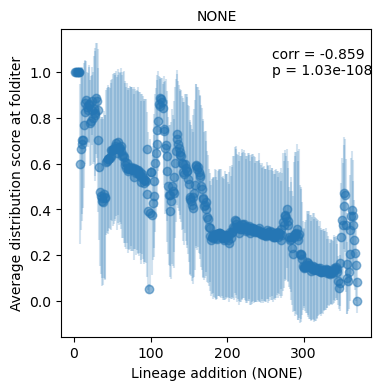

folditer Z00035 vs. average ds at iteration:
p_value = 1.21e-101, corr = -0.845


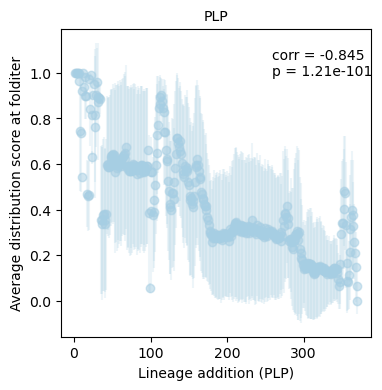

folditer C00002 vs. average ds at iteration:
p_value = 3.94e-96, corr = -0.832


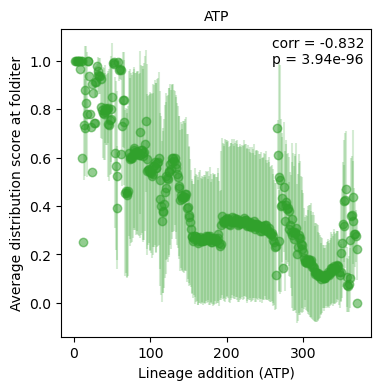

folditer C00004 vs. average ds at iteration:
p_value = 1.08e-95, corr = -0.831


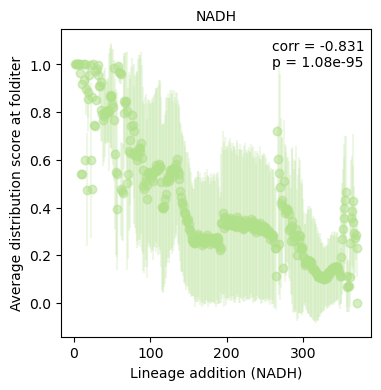

folditer C00019 vs. average ds at iteration:
p_value = 8.27e-83, corr = -0.796


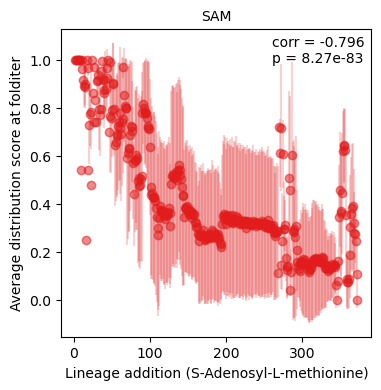

folditer C00010 vs. average ds at iteration:
p_value = 9.96e-86, corr = -0.805


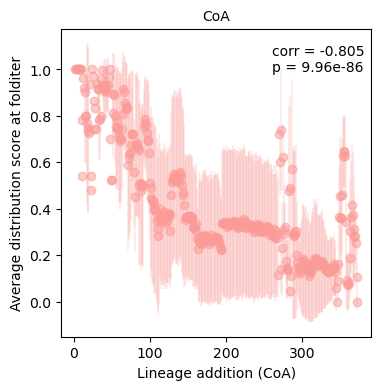

folditer C00016 vs. average ds at iteration:
p_value = 3.57e-85, corr = -0.803


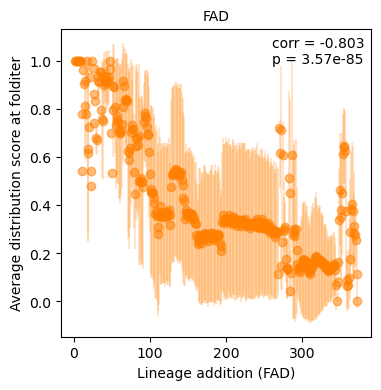

folditer Z00047 vs. average ds at iteration:
p_value = 1.50e-81, corr = -0.793


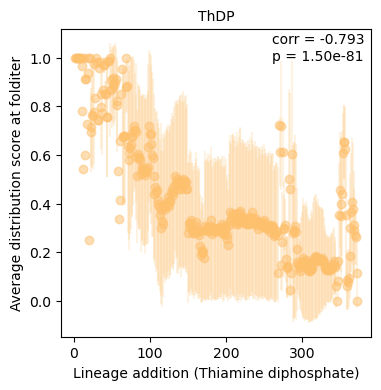

folditer Z00009 vs. average ds at iteration:
p_value = 5.05e-83, corr = -0.797


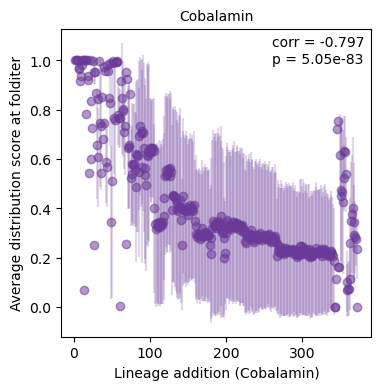

folditer ALL vs. average ds at iteration:
p_value = 1.33e-76, corr = -0.777


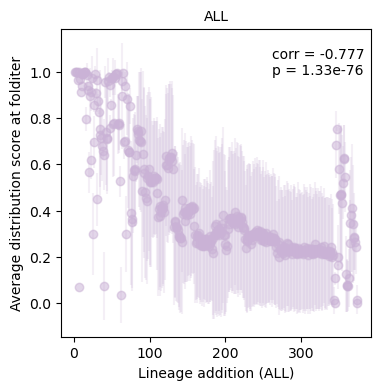

In [16]:
for pre, df in pre2dfs.items():

    run2iter2ds = {}
    for run in df.columns:
        iter2ds = {}
        for x, i in df[run].items():
            if x not in ['fold_independent', 'spontaneous']:
                if i not in iter2ds:
                    iter2ds[i] = [x2ds[x]]
                else:
                    iter2ds[i].append(x2ds[x])
        iter2ds_mean = {k:np.mean(v) for k,v in iter2ds.items()}
        run2iter2ds[run] = iter2ds_mean
    
    iter2ds_mean_all = {}
    for run, iter2ds in run2iter2ds.items():
        for i, ds in iter2ds.items():
            if i not in iter2ds_mean_all:
                iter2ds_mean_all[i] = [ds]
            else:
                iter2ds_mean_all[i].append(ds)
    # take average over 1000 runs
    iter2ds_mean_all_mean = {k:np.mean(v) for k,v in iter2ds_mean_all.items()}
    iter2ds_mean_all_std = {k:np.std(v) for k,v in iter2ds_mean_all.items()}

    # std for error bar
    y = list(iter2ds_mean_all_mean.values())  # average dist score
    x = list(iter2ds_mean_all_mean.keys())  # iteration number
    y_err = list(iter2ds_mean_all_std.values())  # variability 
    
    # Compute Spearman correlation
    corr, p = spearmanr(x, y)
    corr_rounded = round(corr, 3)
    p_sci = f'{p:.2e}'  # Convert p-value to scientific notation
    
    print(f'folditer {pre} vs. average ds at iteration:')
    print(f'p_value = {p_sci}, corr = {corr_rounded}')
    
    # Create a scatterplot with error bars
    plt.figure(figsize=(4, 4))
    plt.errorbar(x, y, yerr=y_err, fmt='o', alpha=0.2, color=pre2color[pre])  # errorbar + data points
    plt.scatter(x, y, marker='o', color=pre2color[pre], alpha=0.4, zorder=2)  # data points
    
    # Annotate correlation on top right (no box)
    plt.text(
        max(x) * 0.7, max(y) * 0.99, 
        f'corr = {corr_rounded}\np = {p_sci}', 
        fontsize=10, ha='left'
    )
    
    plt.ylabel('Average distribution score at folditer')
    plt.xlabel(f'Lineage addition ({cpd2name.get(pre, pre)})')
    plt.title(pre2label[pre], fontsize=10)
    
    # plt.savefig(f'iterVSds_{cpd2name.get(pre, pre)}.png', dpi=300, bbox_inches='tight')
    plt.show()

## SD lineage order (pre-expansions)

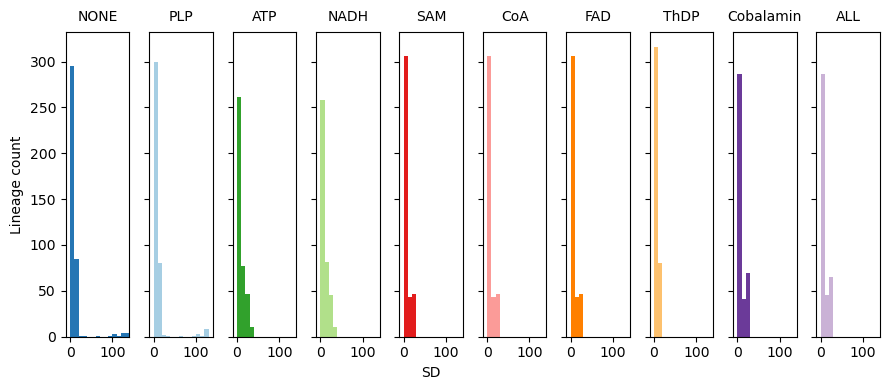

In [17]:
fig, axes = plt.subplots(1, len(pre2dfs), figsize=(0.9 * len(pre2dfs), 4), sharey=True)

# Collect all values to determine a global bin width
all_values = []
for df in pre2dfs.values():
    for x in df.index:
        if x not in ['fold_independent', 'spontaneous']:
            all_values.append(np.std(df.loc[x]))

# Define a fixed bin width based on all data
bin_width = 10  # Set a reasonable bin width (adjust as needed)
bins_range = np.arange(-10, 140 + bin_width, bin_width)  # Common bin edges

# Iterate over each category and its corresponding subplot
for ax, (pre, df) in zip(axes, pre2dfs.items()):
    x2foStd_pre = {}

    # Compute standard deviations
    for x in df.index:
        if x not in ['fold_independent', 'spontaneous']:
            x2foStd_pre[x] = np.std(df.loc[x])

    # Adjust number of bins based on the fixed bin width
    bins = np.arange(-10, 140 + bin_width, bin_width)

    # Plot rotated histogram
    ax.hist(list(x2foStd_pre.values()), bins=bins, color=pre2color[pre], 
            edgecolor=None, orientation='vertical', alpha=1)
    ax.set_xlim([-10, 140]) 

    # Set title & labels for each subplot
    ax.set_title(pre2label[pre], fontsize=10, verticalalignment='bottom')

# Set shared labels
axes[0].set_ylabel("Lineage count")
axes[4].set_xlabel("SD")

# Adjust layout for better spacing
plt.tight_layout()

# plt.savefig("2C_SI_pre-expansions.svg", dpi=300, bbox_inches='tight')
plt.show()

# class composition shift for other pre-expansions

In [18]:
class2color = {'beta':'#163ee4', 'alpha':'#f03b37', 'a+b':'#269d23', 'a/b':'#fcdb24', 'mixed':'#a354f9', 'other':'#808080'}

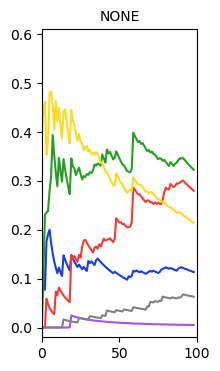

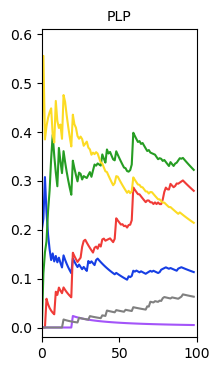

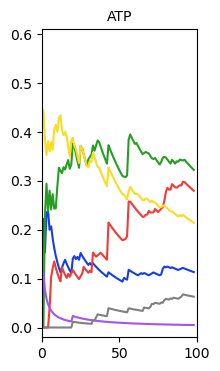

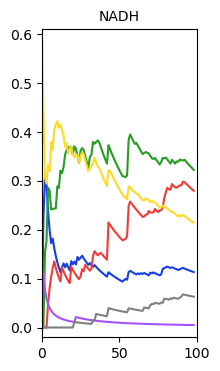

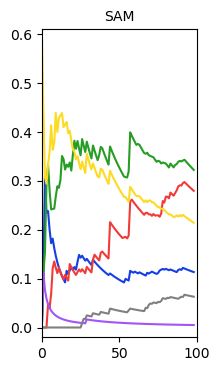

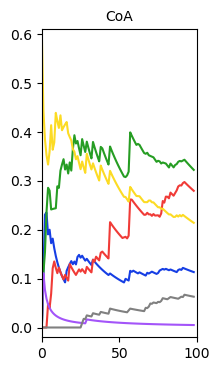

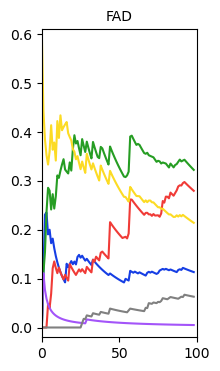

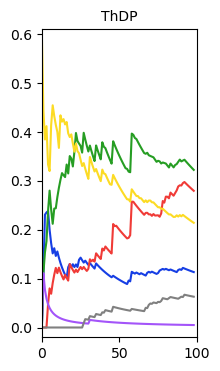

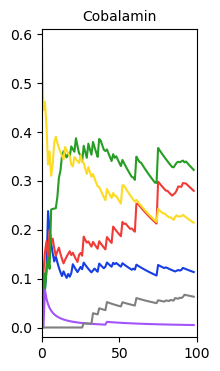

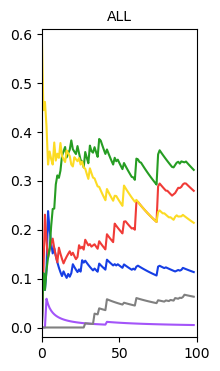

In [19]:
for pre, df in pre2dfs.items():
    x2foMean = {}
    x2foStd = {}
    for x in df.index:
        if x not in ['fold_independent', 'spontaneous']:
            x2foMean[x] = np.mean(df.loc[x])
            x2foStd[x] = np.std(df.loc[x])
    
    x2fo_ranked = {k: rank for rank, (k, v) in enumerate(sorted(x2foMean.items(), key=lambda item: item[1]), start=1)}
    
    plt.figure(figsize=(2, 4))
    for cl in class2color.keys():
        ratios = []
        for cutoff in range(5, 400, 4):
            before_cutoff = [k for k,v in x2foMean.items() if v < cutoff]
            ratios.append([x2class[x] for x in before_cutoff].count(cl)/cutoff)
        
        plt.plot(ratios, color=class2color[cl], label=cl)
    plt.xlim([0, 100])
    plt.ylim([-0.02, 0.61])
    plt.title(pre2label[pre], fontsize=10)
    # plt.savefig(f'class_composition_change_{pre}.svg', dpi=300, bbox_inches='tight')
    plt.show()